In [7]:
import pandas as pd

# Load the dataset
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Display the first 5 rows of the dataset
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [8]:
# Check data types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [9]:
# Convert TotalCharges to numeric, replacing blank spaces with NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check total missing values in TotalCharges
print('Missing TotalCharges count:', df['TotalCharges'].isnull().sum())

# Fill missing values with 0 for new customers (tenure = 0)
df['TotalCharges'] = df['TotalCharges'].fillna(0)

Missing TotalCharges count: 11


In [10]:
# Create a binary column for Churn (Yes = 1, No = 0)
df['Churn_Numeric'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Print the overall Churn Rate
print(
    f'Overall Customer Churn Rate: {df["Churn_Numeric"].mean() * 100:.2f}%'
)

Overall Customer Churn Rate: 26.54%


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_18508\1246071519.py:11: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_18508\1246071519.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_18508\1246071519.py:23: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_18508\1246071519.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_18508\1246071519.py:32: UserWarning: set_ticklabels() should only b

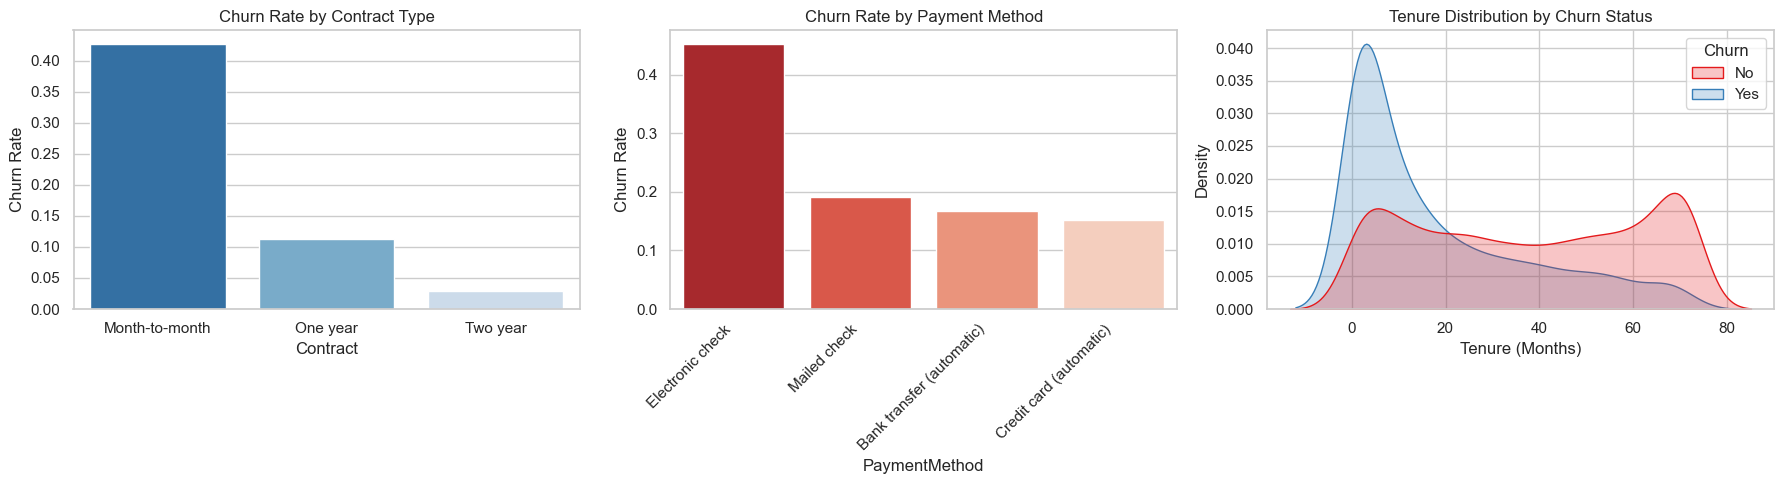

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for visuals
sns.set_theme(style="whitegrid")

# Create a figure with 3 subplots for core churn drivers
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Churn by Contract Type
sns.barplot(
    x='Contract',
    y='Churn_Numeric',
    data=df,
    ax=axes[0],
    ci=None,
    palette='Blues_r',
)
axes[0].set_title('Churn Rate by Contract Type')
axes[0].set_ylabel('Churn Rate')

# 2. Churn by Payment Method
sns.barplot(
    x='PaymentMethod',
    y='Churn_Numeric',
    data=df,
    ax=axes[1],
    ci=None,
    palette='Reds_r',
)
axes[1].set_title('Churn Rate by Payment Method')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
axes[1].set_ylabel('Churn Rate')

# 3. Churn Distribution by Tenure (Months with company)
sns.kdeplot(
    data=df,
    x='tenure',
    hue='Churn',
    common_norm=False,
    shade=True,
    ax=axes[2],
    palette='Set1',
)
axes[2].set_title('Tenure Distribution by Churn Status')
axes[2].set_xlabel('Tenure (Months)')

plt.tight_layout()
plt.show()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_18508\741034755.py:7: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_18508\741034755.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_18508\741034755.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=30, ha='right')
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_18508\741034755.py:7: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_18508\741034755.py:7: FutureWarning: 

Passing `palette` without a

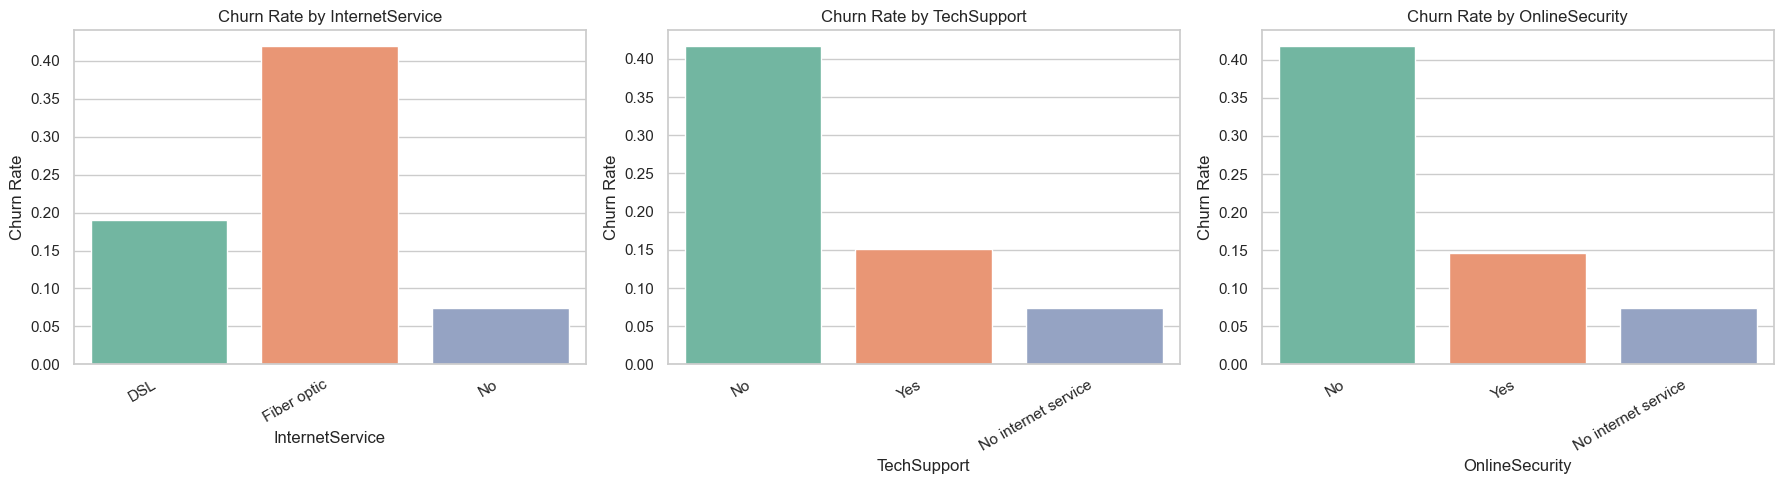

In [12]:
# Analyze Churn Rate across specific services: InternetService, TechSupport, OnlineSecurity
services = ['InternetService', 'TechSupport', 'OnlineSecurity']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, service in enumerate(services):
  sns.barplot(
      x=service,
      y='Churn_Numeric',
      data=df,
      ax=axes[i],
      ci=None,
      palette='Set2',
  )
  axes[i].set_title(f'Churn Rate by {service}')
  axes[i].set_ylabel('Churn Rate')
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.show()

## Executive Summary & Business Insights

### Core Churn Drivers:
1. **Contract Type:** Customers on Month-to-Month contracts exhibit a churn rate over **40%**, compared to under **10%** for 1-2 year contract holders.
2. **Internet & Support Services:** Fiber Optic users show a high churn rate (**~42%**), whereas customers with **TechSupport** packages churn significantly less (**~15%** vs **~41%**).
3. **Tenure & Onboarding:** High customer drop-off occurs within the **first 12 months** of joining.
4. **Payment Method:** Electronic Check users have the highest churn rate (**~45%**) compared to automated payment methods.

### Business Recommendations:
- **Incentivize Long-term Contracts:** Offer discounts or loyalty points for customers switching from Month-to-Month to 1-year contracts.
- **Bundle Support Services:** Provide complimentary TechSupport for the first 6 months to new Fiber Optic subscribers to improve initial retention.
- **Promote Auto-Pay:** Encourage auto-payment adoption with cashback or zero-fee incentives to lower churn associated with manual payments.